# Final Project Notebook

## Shirin's Notebook - Monthly Criminal Reports

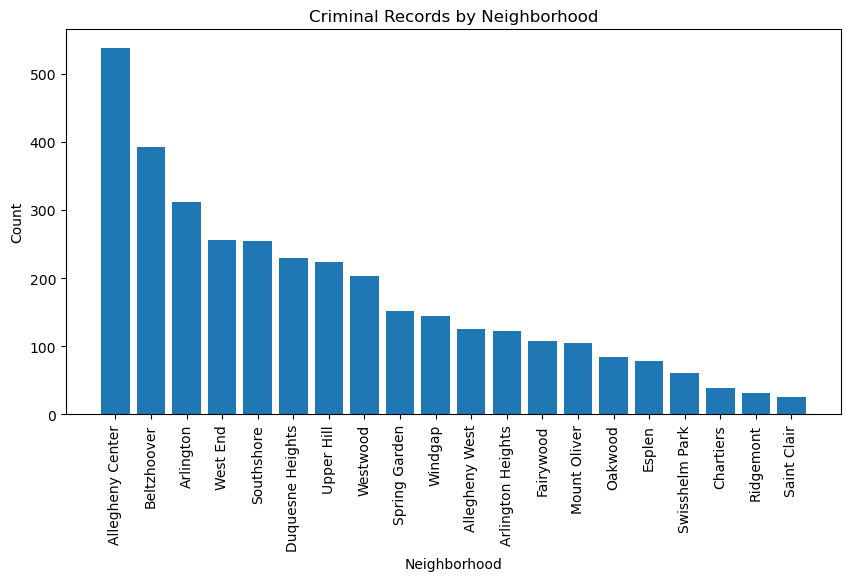

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
#Read the file and sort by neighborhood
criminalData = pd.read_csv("CriminalData.csv", low_memory=False)
criminalData.sort_values(by= 'Neighborhood')





#create a dictionary
dictionary = dict()


#counts theh srime reports per neighborhood and puts them a dictionary
for index, row in criminalData.iterrows():
    if row['Neighborhood'] in dictionary:
        if pd.isna(row['Neighborhood']):
            continue
        dictionary[row['Neighborhood']] += 1
        
    else:
        if pd.isna(row['Neighborhood']):
            continue
        dictionary[row['Neighborhood']] = 1

#Chooses the last 10, or the top 10 neighborhoods with the least crime
last_20 = dict(list(dictionary.items())[-20:])
df = pd.DataFrame(list(last_20.items()), columns=['Neighborhood', 'Count'])


# Sort by count (optional, makes it nicer)
df = df.sort_values(by='Count', ascending=False)



# Plot
plt.figure(figsize=(10,5))
plt.bar(df['Neighborhood'], df['Count'])
plt.xticks(rotation=90)
plt.xlabel('Neighborhood')
plt.ylabel('Count')
plt.title('Criminal Records by Neighborhood')

plt.show()





#for key in dictionary.values():

Group Metric:Quality of Life 
Submetric: Amount of Crime in the Neighborhood I used a dataset that measured the crime reports in each neighborhood in Pittsburgh and the above graph shows the top 20 neighborhoods with the least crime in Pittsburgh. I think this is the best metric because out group metric was quality of life. The crime in your neighborhood is defneitely going ot determine how safe you feel living there which is an important component to your quality of life. So the best neighborhood that we found evidence in all our three datasets was Allegheny. Allegheny had the representation of quality of life in terms of trash, abandoned buildings, and crime.

Conclusion: It is different from my personal preference because I prefer the more populous neighborhoods. But, if I had to live in a neighoborhood in Pittsburgh then I probably would choose Saint Clair.

## Susan's Notebook - Condemned Properties

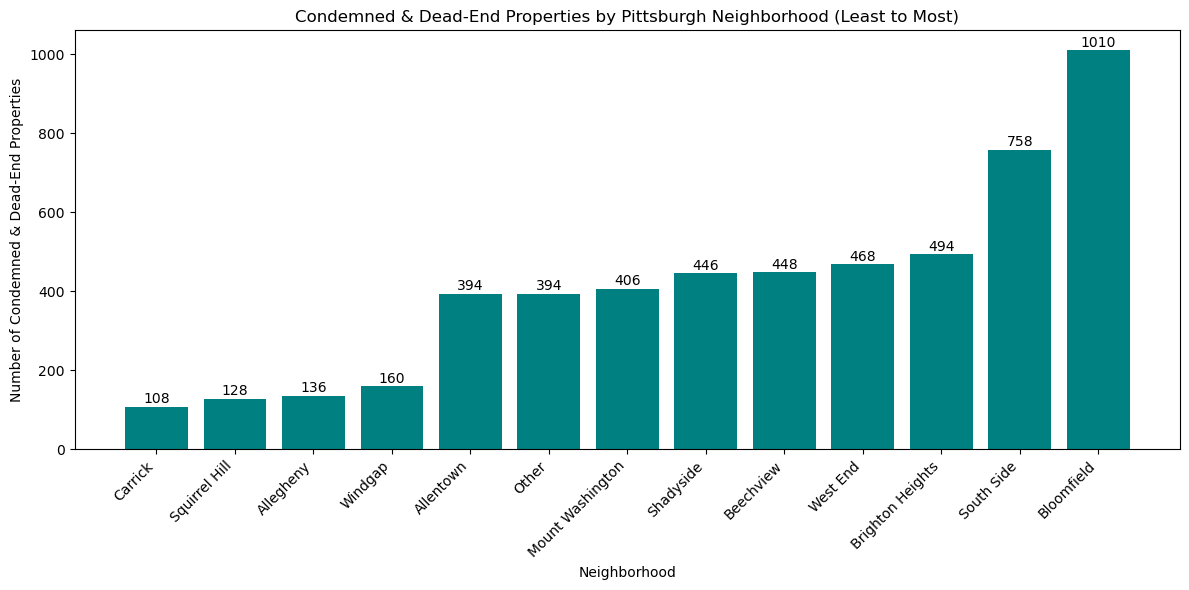

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

#Reading CSV file into notebook
property = pd.read_csv("Condemned_Properties.csv")

#Removing blank rows and rows with 'no primary address'
property = property[property['address'].notna()]
property = property[property['address'] != "No primary address specified"]

#Using split function to extract zip code from valid addresses
property['Zip'] = property['address'].apply(lambda x: x.split(',')[-1].strip())

#Creating a dictionary of top neighborhoods in pgh -> zip code:neighborhood
zip_to_neighborhood = {
    
    '15221': 'Allegheny','15213': 'Oakland', '15224': 'Squirrel Hill', '15206': 'Shadyside',
    '15212': 'South Side', '15217': 'East Liberty', '15232': 'Homewood',
    '15203': 'Carrick', '15210': 'Bloomfield', '15222': 'Downtown',
    '15214': 'Allentown', '15216': 'Brookline', '15218': 'Crafton Heights',
    '15219': 'West End', '15220': 'Windgap', '15201': 'North Shore',
    '15202': 'Strip District', '15204': 'Mount Washington',
    '15205': 'Point Breeze', '15207': 'Beechview', '15208': 'Brighton Heights',
    '15211': 'Mount Washington', '15236': 'Upper Hill'
}

#Keeping zip codes that match with zip codes from our data
property = property[property['Zip'].isin(zip_to_neighborhood.keys())]

#Creating a column for the properties with their corresponding properties
property['Neighborhood'] = property['Zip'].map(zip_to_neighborhood)

#Counting properties per neighborhood
neighborhood_counts = property['Neighborhood'].value_counts()

#Filtering out small neighborhoods (<10 properties) 
#-> want to focus on areas with more data
neighborhood_counts = neighborhood_counts[neighborhood_counts >= 10]

#Creating var. for number of neighborhoods shown in chart
top_count = 12

#Combining smaller neighborhoods into "Other" -> ensures data
#is still represented, but makes chart look more presentable
top = neighborhood_counts.sort_values(ascending=False).head(top_count)
other = neighborhood_counts.sort_values(ascending=False).tail(len(neighborhood_counts) - top_count).sum()
top['Other'] = other

#Sorting bars from smallest to largest number of properties
final_counts = top.sort_values(ascending=True)

#Creating vertical bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(final_counts.index, final_counts.values, color='teal')

#Adding labels to each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,   
        height + 1,                          
        str(int(height)),                    
        ha='center', va='bottom', fontsize=10
    )

#Adding titles and labels for axis and title 
plt.title("Condemned & Dead-End Properties by Pittsburgh Neighborhood (Least to Most)")
plt.xlabel("Neighborhood")
plt.ylabel("Number of Condemned & Dead-End Properties")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Submetric: Unowned/Vacant properties

Dataset from WPRDC: Condemed & Dead-End Properties (CSV File, 4,000+ entries)

Condemned & Dead-End Properties are buildings that the city of Pittsburgh has labeled unsafe or beyond repair, so they are basically vacant properties. Also, by law they cannot be lived in until they are fixed or torn down.

Information found: Addresses(zip code), owner, property type, latest inspection result

Group metric: Quality of life

How it connects: This chart shows how many unsafe or abandoned buildings exist in each neighborhood. Higher counts of these properties indicate worse housing conditions and lower neighborhood safety which directly impacts residents’ quality of life.

## Mariah's Notebook - Smart Trash Containers

A program started in 2017 has lead to a large increase in smart trash containers in the neighborhoods of Pittsburgh as of 2019. These trash containers are public waste bins found around the neighborhoods that have fill-level sensors which communicate when the bin is nearing capacity and sends an alert to the city's Department of Public Works (DPW). Because trash containers are now being maintained better, there is a large reduce in litter and pests since there isn't trash overfilling the containers. This therefore provides cleaner public spaces and a better quality of life for the community. These alerts also help with lowering the emissions of greenhouse gases since the DPW is able to know when to change a trash container rather than following a fixed schedule every day.

In [3]:
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import csv
df = pd.read_csv('SmartTrashContainers.csv')

trash_counts = df['neighborhood'].value_counts()

print(f"Total neighborhoods: {trash_counts.size}")

for neighborhood, count in trash_counts.items():
    print(f"{neighborhood}: {count}")

top_20 = trash_counts.head(20)

Total neighborhoods: 79
Shadyside: 76
East Liberty: 68
Squirrel Hill South: 63
Bloomfield: 58
North Shore: 53
South Side Flats: 51
Strip District: 42
Carrick: 38
Central Oakland: 34
Central Lawrenceville: 29
Middle Hill: 29
Lower Lawrenceville: 29
Bluff: 28
Homewood South: 28
East Allegheny: 26
Mount Washington: 25
Brighton Heights: 24
Squirrel Hill North: 22
Crawford-Roberts: 21
Larimer: 20
Hazelwood: 18
Marshall-Shadeland: 17
Brookline: 17
Sheraden: 16
Perry North: 15
Troy Hill: 15
Allegheny West: 15
Upper Lawrenceville: 15
North Oakland: 14
Greenfield: 14
Polish Hill: 13
Perry South: 12
Elliott: 12
Friendship: 12
Highland Park: 12
Point Breeze: 12
Central Northside: 10
West End: 9
Regent Square: 9
Allentown: 9
Morningside: 8
Crafton Heights: 8
South Side Slopes: 8
West Oakland: 8
Beechview: 8
Allegheny Center: 7
Lincoln Place: 7
South Oakland: 7
Garfield: 7
Knoxville: 7
Upper Hill: 7
Central Business District: 7
Manchester: 6
Lincoln-Lemington-Belmar: 6
Spring Hill-City View: 5
West

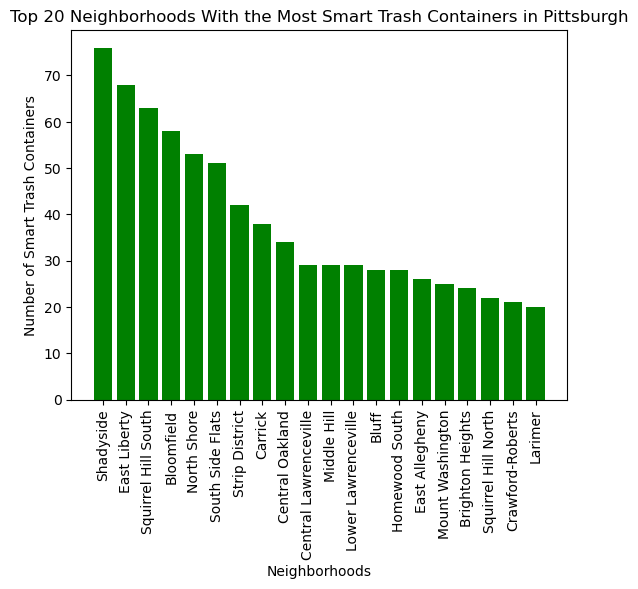

In [4]:
plt.bar(top_20.index, top_20.values, color='green') #change color to green
plt.xlabel('Neighborhoods')
plt.ylabel('Number of Smart Trash Containers')
plt.title('Top 20 Neighborhoods With the Most Smart Trash Containers in Pittsburgh')
plt.xticks(rotation=90)
plt.show()

The bar graph above reprsents the top 20 neighborhoods in Pittsburgh that have the most smart trash containers with Shadyside having a total of 76 trash containers. Between the three datasets, there is an overlap with the Allegheny neighborhood. These containers are very efficient in keeping the enviornment clean for the community!